# EDA 05 — Merged Analytical Dataset of Road closures and train moments

**Source**: Output of `geo.find_nearby_stations()` + `features.filter_within_time_window()`  
**Reads from**: `data/processed/road_closures_clean.parquet` + `data/processed/train_moments_clean.parquet`  
**Output**: `data/processed/road_train_moments_dataset.parquet`  consumed by `rail_delay_prediction.ipynb`

This notebook performs EDA on the merged analytical dataset that results from the spatial join (10-25 km haversine) and temporal filter (0-60 minute post-closure window). This is the dataset the model trains on. Exploring it here keeps the main analysis notebook focused purely on modelling.

---
**Sections**
1. Rebuild the analytical dataset from processed parquets  
2. Dataset overview and shape  
3. Delay (target variable) distribution  
4. Predictor distributions (distance, time)  
5. Categorical distributions (closure type, event type)  
6. Bivariate relationships (scatter, heatmap, correlation)  
7. Temporal patterns (hour of day, day of week)  
8. Spatial patterns (stations, closure impact)  
9. Save output  


## 0. Setup

In [47]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "..")
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 40)
os.makedirs("figures/eda_05", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Rebuild Analytical Dataset

Rather than re-downloading from Azure, read the processed parquet files saved by EDA 02 and EDA 03, then re-run the spatial join and temporal filter. This keeps the EDA self-contained and fast.

In [48]:
from datetime import datetime, timezone
from src.geo import find_nearby_stations
from src.features import (
    merge_on_station, filter_within_time_window
)

# Load from processed parquets where available, else re-fetch
import os
stations_reference_path = "./data/processed/stations_reference.parquet"
road_path  = "./data/processed/road_closures_clean.parquet"
train_path = "./data/processed/train_moments_clean.parquet"

if os.path.exists(road_path) and os.path.exists(train_path):
    road_df  = pd.read_parquet(road_path)
    train_df = pd.read_parquet(train_path)
    stations_ref_df = pd.read_parquet(stations_reference_path)
    print(f"Loaded from parquet: {len(road_df):,} closures, {len(train_df):,} train moments, {len(stations_ref_df):,} stations")
else:
    print("Processed parquets not found — run EDA 01 and EDA 02 first.")
    raise FileNotFoundError("Missing processed parquets")

Loaded from parquet: 296 closures, 39,091 train moments, 2,594 stations


In [49]:
# Spatial join
expanded_road_df = find_nearby_stations(road_df, stations_ref_df, min_km=10, max_km=25)
print(f"Closure-station pairs: {len(expanded_road_df):,}")
display(expanded_road_df.head())
display(train_df.head())

Closure-station pairs: 16,361


,closure_id,closure_lat,closure_lon,closure_type,closure_start_time,closure_end_time,start_hour,start_dow,start_date,validity_status,cause_type,station_name,station_lat,station_lon,station_code,stanox,tpl,distance_in_km,road_ingestion_time
0,481398,52.241032,0.056728,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,19,5,2026-04-11,planned,roadMaintenance,Dullingham,52.201649,0.366664,DUL,47006,DULNGHM,21.561992,2026-04-11 05:09:20.728518
1,481398,52.241032,0.056728,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,19,5,2026-04-11,planned,roadMaintenance,Ely,52.391228,0.266828,ELY,46273,ELYY,21.974512,2026-04-11 05:09:20.728518
2,481398,52.241032,0.056728,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,19,5,2026-04-11,planned,roadMaintenance,Foxton,52.119212,0.056308,FXN,47242,FOXTON,13.545760,2026-04-11 05:09:20.728518
3,481398,52.241032,0.056728,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,19,5,2026-04-11,planned,roadMaintenance,Great Chesterford,52.059809,0.193521,GRC,47311,GTCHSFD,22.207451,2026-04-11 05:09:20.728518
4,481398,52.241032,0.056728,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,19,5,2026-04-11,planned,roadMaintenance,Huntingdon,52.328648,-0.192068,HUN,45201,HNTNGDN,19.527520,2026-04-11 05:09:20.728518


,train_id,actual_timestamp,planned_timestamp,gbtt_timestamp,loc_stanox,next_stanox,event_type,planned_event_type,variation_status,timetable_variation,platform,route,direction,train_terminated,delay_monitoring_point,msg_timestamp,data_source,is_delayed,station_code,actual_hour,actual_dow,actual_date
0,015H562C10,2026-04-10 08:15:00,2026-04-10 08:20:30,2026-04-10 08:20:00,1008.0,NaN,DEPARTURE,DEPARTURE,EARLY,5.0,<NA>,<NA>,None,True,True,1.775811e+12,SDR,0.0,GGJ,8.0,4.0,2026-04-10
1,512O17MF10,2026-04-10 09:47:00,2026-04-10 09:47:30,2026-04-10 09:48:00,51717.0,51720.0,ARRIVAL,ARRIVAL,ON TIME,0.0,1,0.0,UP,False,False,1.775811e+12,SMART,0.0,RYH,9.0,4.0,2026-04-10
2,522S14ME10,2026-04-10 09:46:00,2026-04-10 09:46:00,NaT,51914.0,51913.0,DEPARTURE,DEPARTURE,ON TIME,0.0,2,1.0,DOWN,False,True,1.775811e+12,SMART,0.0,BMD,9.0,4.0,2026-04-10
3,525E20MF10,2026-04-10 09:47:00,NaT,NaT,52705.0,NaN,ARRIVAL,ARRIVAL,OFF ROUTE,0.0,<NA>,<NA>,None,False,False,1.775811e+12,SMART,0.0,LHS,9.0,4.0,2026-04-10
4,522T37MF10,2026-04-10 09:47:00,2026-04-10 09:46:30,2026-04-10 09:47:00,52729.0,52733.0,ARRIVAL,ARRIVAL,LATE,1.0,1,0.0,UP,False,False,1.775811e+12,SMART,1.0,WST,9.0,4.0,2026-04-10


In [53]:
# Merge with train moments
merged_df = merge_on_station(expanded_road_df, train_df)
print(f"After merge: {len(merged_df):,} rows")

# Temporal filter: 0-60 minutes post-closure
filtered_df = filter_within_time_window(merged_df, window_minutes=60)
print(f"After 60-min filter: {len(filtered_df):,} rows")

# Select final columns
keep_cols = [
    "closure_id", "closure_type", "closure_lat", "closure_lon",
    "validity_status", "cause_type",
    "distance_in_km", "station_name", "stanox",
    "closure_start_time", "actual_timestamp", "planned_timestamp",
    "planned_time_diff", "event_type",
    "start_hour","start_dow","duration_hours"
]
filtered_df = filtered_df[[c for c in keep_cols if c in filtered_df.columns]].copy()

# Compute delay
filtered_df["actual_timestamp"]  = pd.to_datetime(filtered_df["actual_timestamp"])
filtered_df["planned_timestamp"] = pd.to_datetime(filtered_df["planned_timestamp"])
filtered_df["delay"] = (
    filtered_df["actual_timestamp"] - filtered_df["planned_timestamp"]
).dt.total_seconds() / 60

# Interaction feature
filtered_df["distance_time_interaction"] = (
    filtered_df["distance_in_km"] * filtered_df["planned_time_diff"]
)

print(f"\nFinal analytical dataset: {len(filtered_df):,} rows")
filtered_df.head()

After merge: 96,277 rows
After 60-min filter: 5,446 rows

Final analytical dataset: 5,446 rows


,closure_id,closure_type,closure_lat,closure_lon,validity_status,cause_type,distance_in_km,station_name,stanox,closure_start_time,actual_timestamp,planned_timestamp,planned_time_diff,event_type,start_hour,start_dow,delay,distance_time_interaction
79,483341,planned,51.362305,-2.889965,planned,constructionWork,22.269165,Bedminster,81813,2026-04-10 19:00:00,2026-04-10 19:56:00,2026-04-10 19:55:30,55.5,ARRIVAL,19,4,0.5,1235.938657
103,483341,planned,51.362305,-2.889965,planned,constructionWork,22.435264,Cardiff Bay,78456,2026-04-10 19:00:00,2026-04-10 19:59:00,2026-04-10 19:53:00,53.0,ARRIVAL,19,4,6.0,1189.069015
142,483341,planned,51.362305,-2.889965,planned,constructionWork,23.716110,Cardiff Central,77301,2026-04-10 19:00:00,2026-04-10 19:28:00,2026-04-10 19:28:00,28.0,DEPARTURE,19,4,0.0,664.051071
143,483341,planned,51.362305,-2.889965,planned,constructionWork,23.716110,Cardiff Central,77301,2026-04-10 19:00:00,2026-04-10 19:46:00,2026-04-10 19:27:00,27.0,ARRIVAL,19,4,19.0,640.334961
145,483341,planned,51.362305,-2.889965,planned,constructionWork,23.716110,Cardiff Central,77301,2026-04-10 19:00:00,2026-04-10 19:53:00,2026-04-10 19:56:00,56.0,DEPARTURE,19,4,-3.0,1328.102142


## 2. Dataset Overview

In [54]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5446 entries, 79 to 94947
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   closure_id                 5446 non-null   object        
 1   closure_type               5446 non-null   object        
 2   closure_lat                5446 non-null   float64       
 3   closure_lon                5446 non-null   float64       
 4   validity_status            5446 non-null   object        
 5   cause_type                 5446 non-null   object        
 6   distance_in_km             5446 non-null   float64       
 7   station_name               5446 non-null   object        
 8   stanox                     5446 non-null   object        
 9   closure_start_time         5446 non-null   datetime64[ns]
 10  actual_timestamp           5446 non-null   datetime64[ns]
 11  planned_timestamp          5446 non-null   datetime64[ns]
 12  planned_t

In [55]:
print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
print(f"Total rows:             {len(filtered_df):,}")
print(f"Unique stations:        {filtered_df['station_name'].nunique():,}")
print(f"Unique closures:        {filtered_df['closure_id'].nunique():,}")
print(f"Date range (planned):   {filtered_df['planned_timestamp'].min()} — {filtered_df['planned_timestamp'].max()}")
print()
print("By closure type:")
print(filtered_df["closure_type"].value_counts().to_string())
print()
print("By event type:")
print(filtered_df["event_type"].value_counts().to_string())

DATASET SUMMARY
Total rows:             5,446
Unique stations:        854
Unique closures:        126
Date range (planned):   2026-04-09 21:56:30 — 2026-04-12 22:59:00

By closure type:
closure_type
unplanned    2995
planned      2451

By event type:
event_type
DEPARTURE    2773
ARRIVAL      2673


## 3. Delay (Target Variable) Distribution

In [56]:
delay = filtered_df["delay"]
print("Delay statistics (minutes):")
print(delay.describe().round(3))
print(f"\nSkewness: {delay.skew():.4f}")
print(f"Kurtosis: {delay.kurtosis():.4f}")
print()
print("Quantiles:")
print(delay.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2))

Delay statistics (minutes):
count    5446.000
mean        1.000
std         5.664
min      -104.000
25%        -0.500
50%         0.000
75%         1.500
max        52.500
Name: delay, dtype: float64

Skewness: -2.9236
Kurtosis: 85.8512

Quantiles:
0.01   -11.55
0.05    -1.50
0.25    -0.50
0.50     0.00
0.75     1.50
0.95     8.50
0.99    22.50
Name: delay, dtype: float64


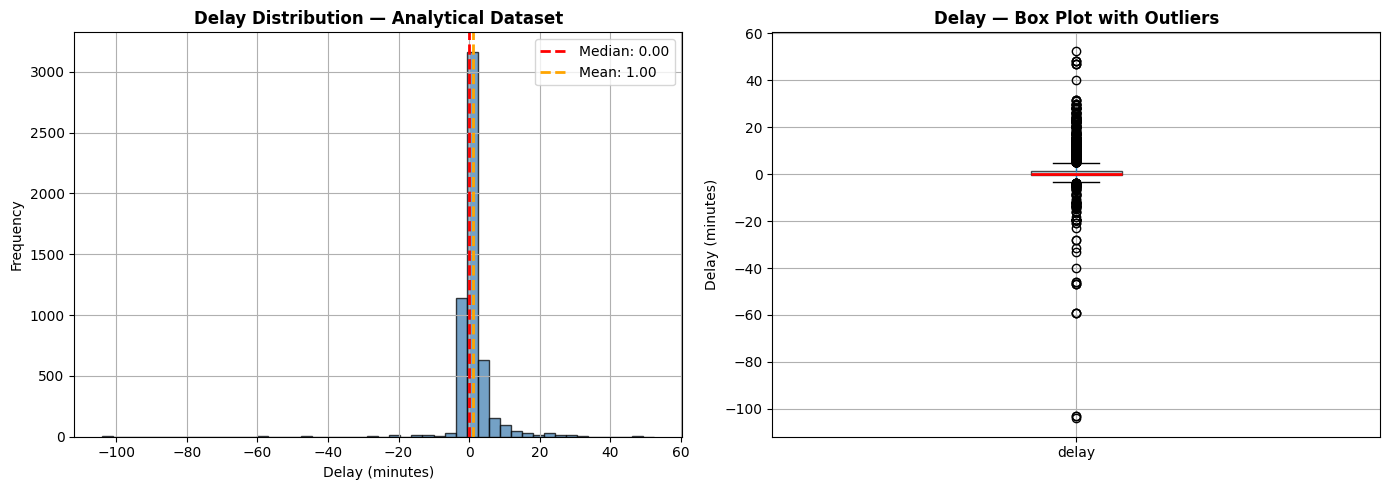

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

delay.hist(bins=50, ax=axes[0], edgecolor="black", alpha=0.75, color="steelblue")
axes[0].axvline(delay.median(), color="red", linestyle="--", lw=2,
                label=f"Median: {delay.median():.2f}")
axes[0].axvline(delay.mean(), color="orange", linestyle="--", lw=2,
                label=f"Mean: {delay.mean():.2f}")
axes[0].set_xlabel("Delay (minutes)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Delay Distribution — Analytical Dataset", fontweight="bold")
axes[0].legend()

filtered_df.boxplot(column="delay", vert=True, ax=axes[1], patch_artist=True,
                    boxprops=dict(facecolor="lightblue", alpha=0.7),
                    medianprops=dict(color="red", linewidth=2))
axes[1].set_ylabel("Delay (minutes)")
axes[1].set_title("Delay — Box Plot with Outliers", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/eda_05/delay_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

In [58]:
# Outlier investigation
extreme_early = filtered_df[filtered_df["delay"] < -30]
extreme_late  = filtered_df[filtered_df["delay"] > 30]
print(f"Extreme early (< -30 min): {len(extreme_early):,} ({len(extreme_early)/len(filtered_df)*100:.2f}%)")
print(f"Extreme late  (> 30 min):  {len(extreme_late):,} ({len(extreme_late)/len(filtered_df)*100:.2f}%)")
if len(extreme_late):
    print("\nSample extreme late records:")
    display(extreme_late[["station_name","planned_timestamp","actual_timestamp","delay","closure_type"]].head(10))

Extreme early (< -30 min): 14 (0.26%)
Extreme late  (> 30 min):  12 (0.22%)

Sample extreme late records:


,station_name,planned_timestamp,actual_timestamp,delay,closure_type
146,Cardiff Central,2026-04-10 19:25:00,2026-04-10 20:05:00,40.0,planned
19084,Shortlands,2026-04-12 21:30:30,2026-04-12 22:23:00,52.5,planned
20270,Kirk Sandall,2026-04-12 19:31:30,2026-04-12 20:03:00,31.5,planned
20373,Kirk Sandall,2026-04-12 19:31:30,2026-04-12 20:03:00,31.5,planned
20475,Kirk Sandall,2026-04-12 19:31:30,2026-04-12 20:03:00,31.5,planned
23853,Victoria,2026-04-10 22:03:00,2026-04-10 22:50:00,47.0,planned
32401,Victoria,2026-04-10 22:03:00,2026-04-10 22:50:00,47.0,planned
63194,Bromley South,2026-04-10 13:30:00,2026-04-10 14:01:00,31.0,unplanned
69518,Victoria,2026-04-10 22:03:00,2026-04-10 22:50:00,47.0,unplanned
81048,Garforth,2026-04-10 12:39:00,2026-04-10 13:27:00,48.0,unplanned


## 4. Predictor Distributions

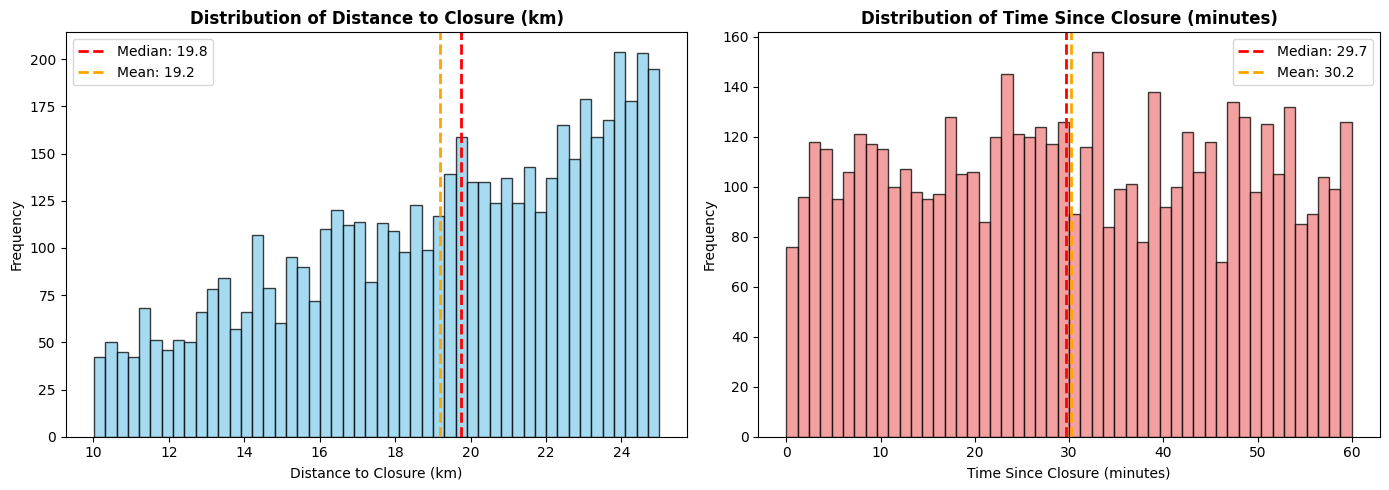

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, color, label in [
    (axes[0], "distance_in_km", "skyblue", "Distance to Closure (km)"),
    (axes[1], "planned_time_diff", "lightcoral", "Time Since Closure (minutes)")
]:
    s = filtered_df[col]
    ax.hist(s, bins=50, edgecolor="black", alpha=0.75, color=color)
    ax.axvline(s.median(), color="red", linestyle="--", lw=2, label=f"Median: {s.median():.1f}")
    ax.axvline(s.mean(), color="orange", linestyle="--", lw=2, label=f"Mean: {s.mean():.1f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")
    ax.set_title(f"Distribution of {label}", fontweight="bold")
    ax.legend()
plt.tight_layout()
plt.savefig("figures/eda_05/predictor_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Categorical Distributions

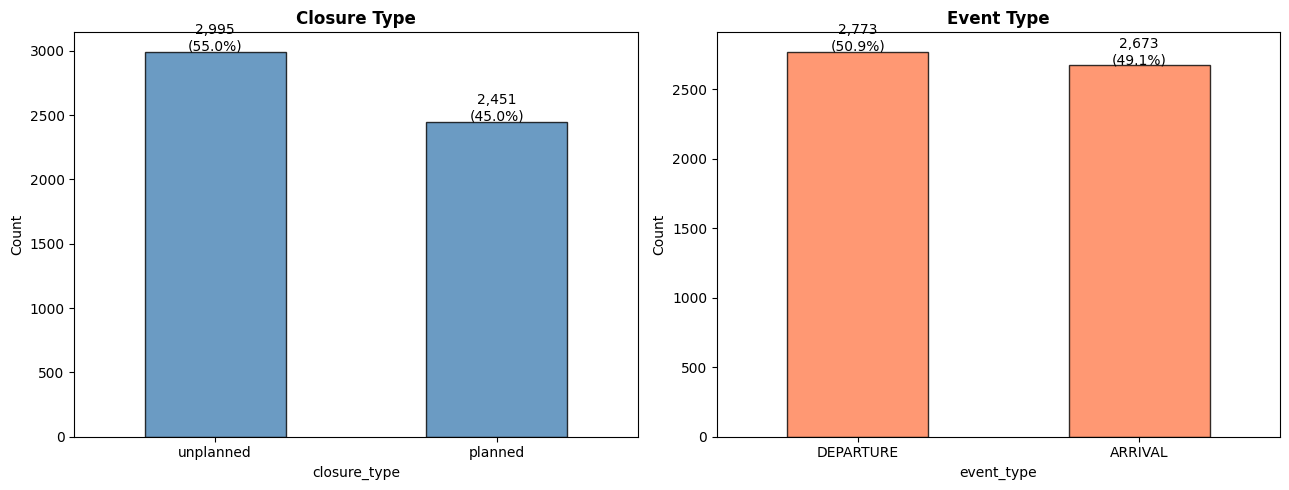

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ct = filtered_df["closure_type"].value_counts()
ct.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Closure Type", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(ct.values):
    axes[0].text(i, v + 10, f"{v:,}\n({v/len(filtered_df)*100:.1f}%)", ha="center", fontsize=10)

et = filtered_df["event_type"].value_counts()
et.plot(kind="bar", ax=axes[1], color="coral", edgecolor="black", alpha=0.8)
axes[1].set_title("Event Type", fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
for i, v in enumerate(et.values):
    axes[1].text(i, v + 10, f"{v:,}\n({v/len(filtered_df)*100:.1f}%)", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("figures/eda_05/categorical_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

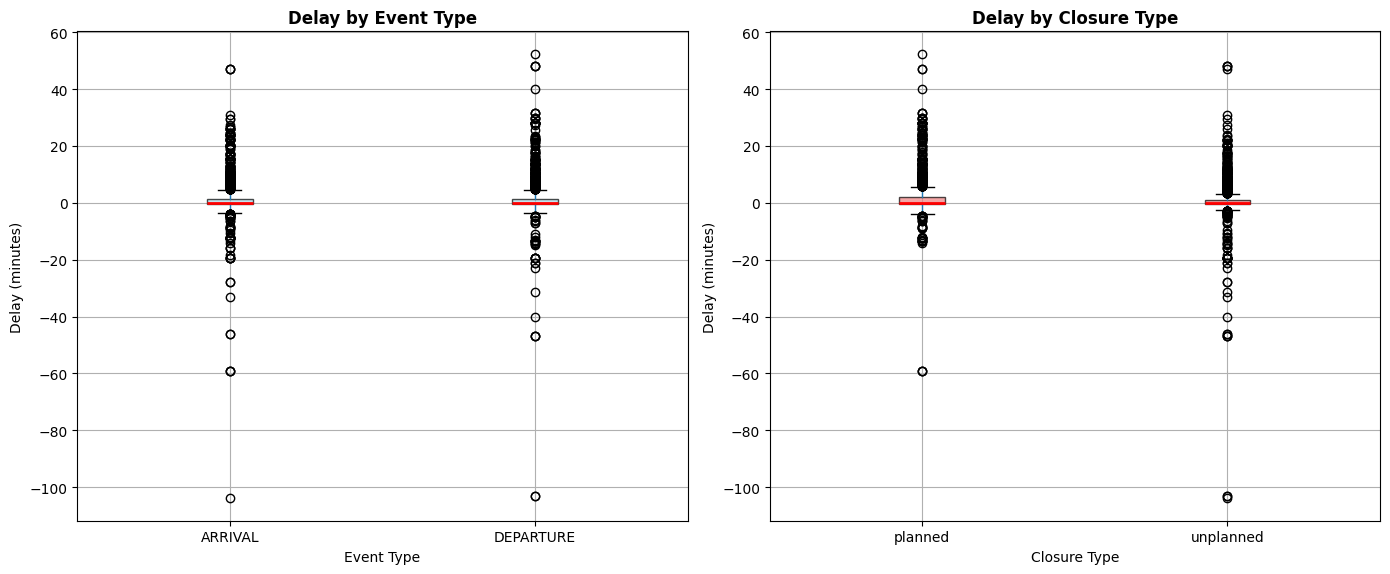


Mean delay by event type:
             mean  median    std  count
event_type                             
ARRIVAL     0.967     0.0  5.602   2673
DEPARTURE   1.031     0.0  5.723   2773

Mean delay by closure type:
               mean  median    std  count
closure_type                             
planned       1.588     0.0  5.549   2451
unplanned     0.519     0.0  5.712   2995


In [61]:
# Delay by categorical variables
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
filtered_df.boxplot(column="delay", by="event_type", ax=axes[0], patch_artist=True,
                    boxprops=dict(facecolor="lightblue", alpha=0.7),
                    medianprops=dict(color="red", linewidth=2))
axes[0].set_title("Delay by Event Type", fontweight="bold")
axes[0].set_xlabel("Event Type")
axes[0].set_ylabel("Delay (minutes)")
plt.suptitle("")

filtered_df.boxplot(column="delay", by="closure_type", ax=axes[1], patch_artist=True,
                    boxprops=dict(facecolor="lightcoral", alpha=0.7),
                    medianprops=dict(color="red", linewidth=2))
axes[1].set_title("Delay by Closure Type", fontweight="bold")
axes[1].set_xlabel("Closure Type")
axes[1].set_ylabel("Delay (minutes)")
plt.suptitle("")
plt.tight_layout()
plt.savefig("figures/eda_05/delay_by_categories.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nMean delay by event type:")
print(filtered_df.groupby("event_type")["delay"].agg(["mean","median","std","count"]).round(3))
print("\nMean delay by closure type:")
print(filtered_df.groupby("closure_type")["delay"].agg(["mean","median","std","count"]).round(3))

## 6. Bivariate Relationships

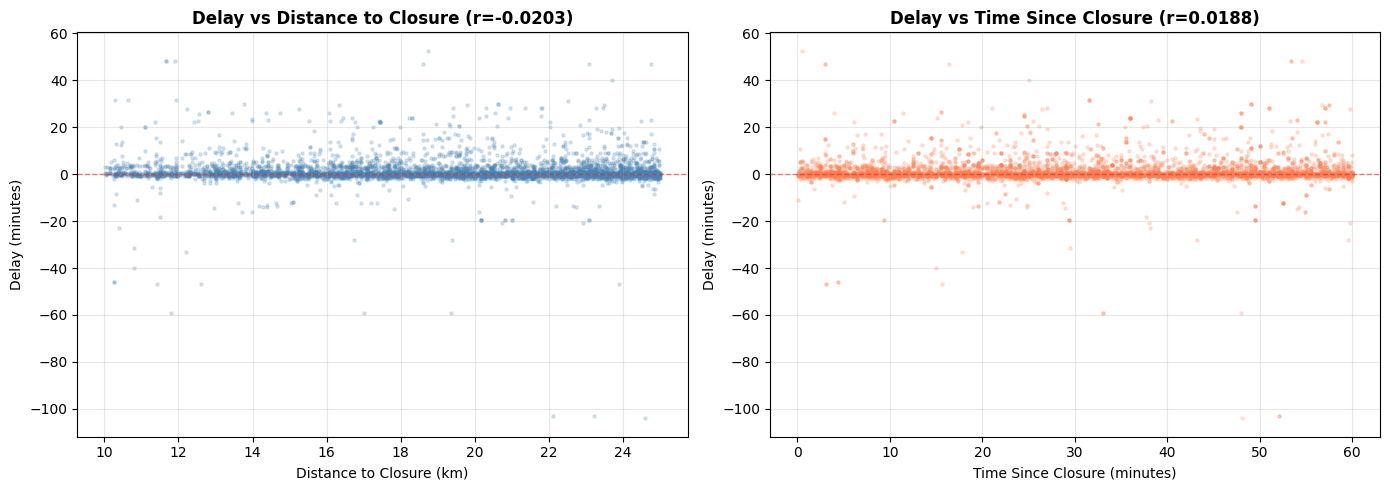

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, color, xlabel in [
    (axes[0], "distance_in_km", "steelblue", "Distance to Closure (km)"),
    (axes[1], "planned_time_diff", "coral", "Time Since Closure (minutes)")
]:
    ax.scatter(filtered_df[col], filtered_df["delay"],
               alpha=0.2, s=5, color=color)
    ax.axhline(0, color="red", linestyle="--", lw=1, alpha=0.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Delay (minutes)")
    corr = filtered_df[[col,"delay"]].corr().iloc[0,1]
    ax.set_title(f"Delay vs {xlabel.split('(')[0].strip()} (r={corr:.4f})", fontweight="bold")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/eda_05/scatter_delay_vs_predictors.png", dpi=200, bbox_inches="tight")
plt.show()

C:\Users\home\AppData\Local\Temp\ipykernel_16256\214596273.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = hm.pivot_table(values="delay", index="dist_bin", columns="time_bin", aggfunc="mean")


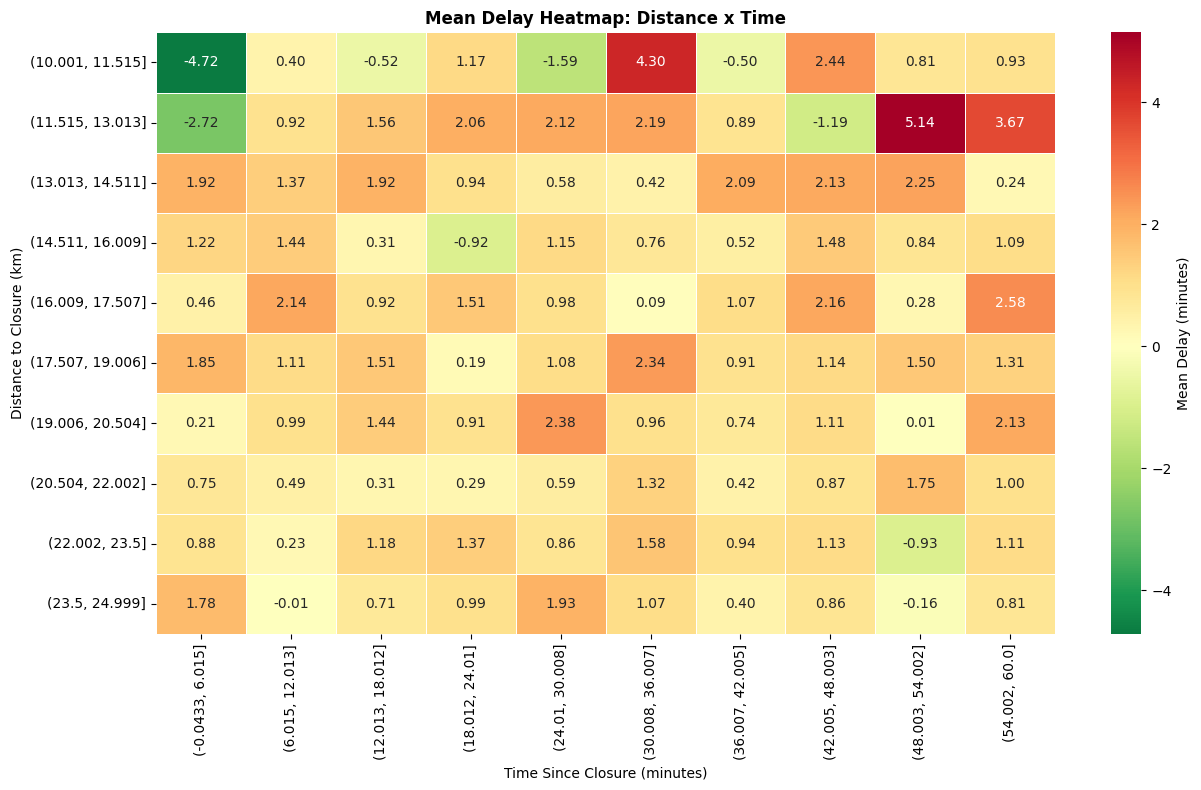

In [63]:
# Distance x time heatmap
hm = filtered_df.copy()
hm["dist_bin"] = pd.cut(hm["distance_in_km"], bins=10)
hm["time_bin"] = pd.cut(hm["planned_time_diff"], bins=10)
pivot = hm.pivot_table(values="delay", index="dist_bin", columns="time_bin", aggfunc="mean")

plt.figure(figsize=(13, 8))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn_r", center=0,
            cbar_kws={"label": "Mean Delay (minutes)"}, linewidths=0.5)
plt.xlabel("Time Since Closure (minutes)")
plt.ylabel("Distance to Closure (km)")
plt.title("Mean Delay Heatmap: Distance x Time", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_05/heatmap_distance_time.png", dpi=200, bbox_inches="tight")
plt.show()

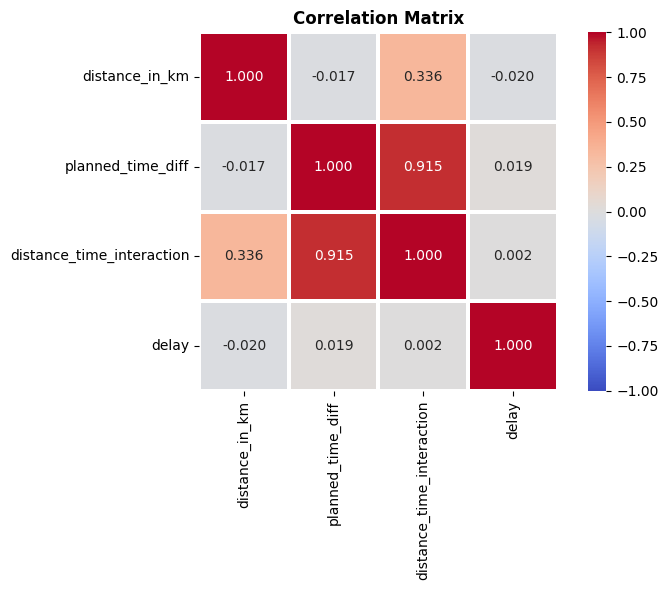


Correlation with delay:
distance_in_km              -0.020312
distance_time_interaction    0.001697
planned_time_diff            0.018766
Name: delay, dtype: float64


In [64]:
# Correlation matrix
numeric_cols = ["distance_in_km", "planned_time_diff", "distance_time_interaction", "delay"]
corr_matrix = filtered_df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            square=True, linewidths=1.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_05/correlation_matrix.png", dpi=200, bbox_inches="tight")
plt.show()
print("\nCorrelation with delay:")
print(corr_matrix["delay"].drop("delay").sort_values())

## 7. Temporal Patterns

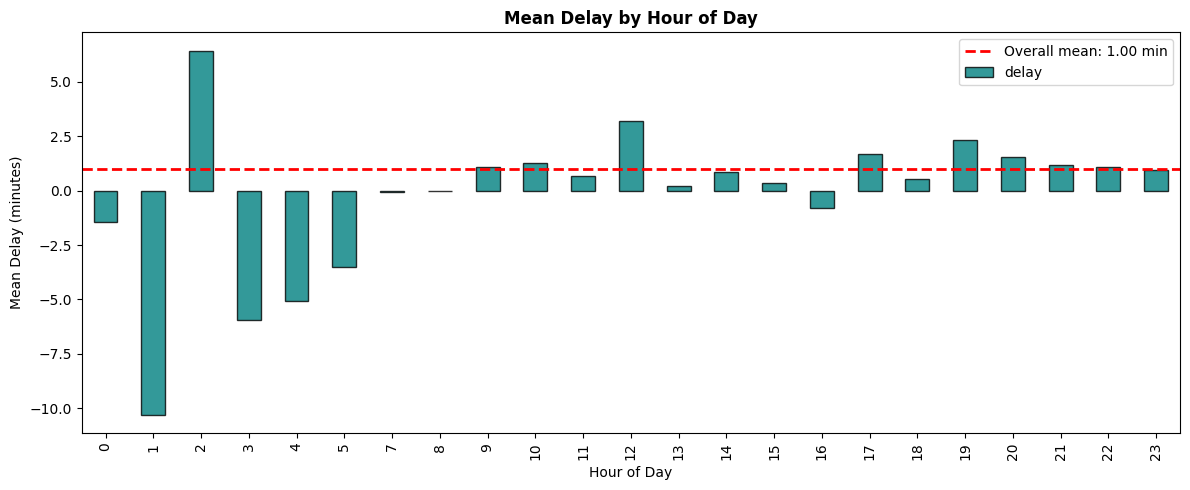

In [65]:
filtered_df["hour"] = filtered_df["planned_timestamp"].dt.hour
hourly = filtered_df.groupby("hour")["delay"].mean()

plt.figure(figsize=(12, 5))
hourly.plot(kind="bar", color="teal", edgecolor="black", alpha=0.8)
plt.xlabel("Hour of Day")
plt.ylabel("Mean Delay (minutes)")
plt.title("Mean Delay by Hour of Day", fontweight="bold")
plt.axhline(filtered_df["delay"].mean(), color="red", linestyle="--", lw=2,
            label=f"Overall mean: {filtered_df['delay'].mean():.2f} min")
plt.legend()
plt.tight_layout()
plt.savefig("figures/eda_05/delay_by_hour.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Spatial Patterns

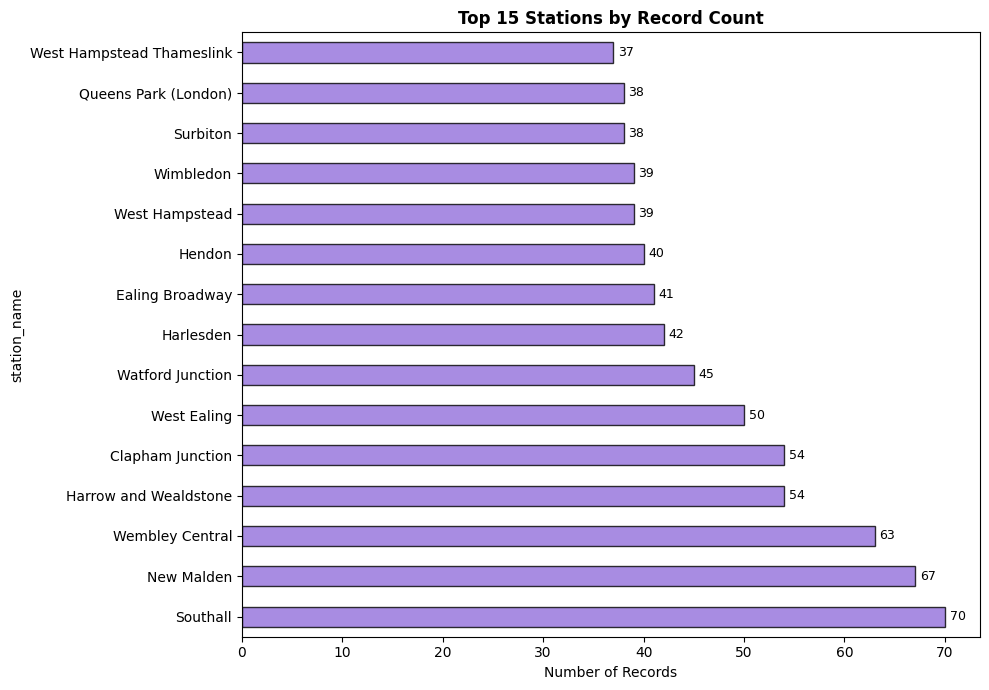

Top 15 stations: 717 rows (13.2% of total)


In [66]:
top_stations = filtered_df["station_name"].value_counts().head(15)
plt.figure(figsize=(10, 7))
top_stations.plot(kind="barh", color="mediumpurple", edgecolor="black", alpha=0.8)
plt.xlabel("Number of Records")
plt.title("Top 15 Stations by Record Count", fontweight="bold")
for i, v in enumerate(top_stations.values):
    plt.text(v + 0.5, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("figures/eda_05/top_stations.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Top 15 stations: {top_stations.sum():,} rows ({top_stations.sum()/len(filtered_df)*100:.1f}% of total)")

Unique closures: 126
Mean rows per closure:   43.2
Median rows per closure: 13.5
Max rows per closure:    334


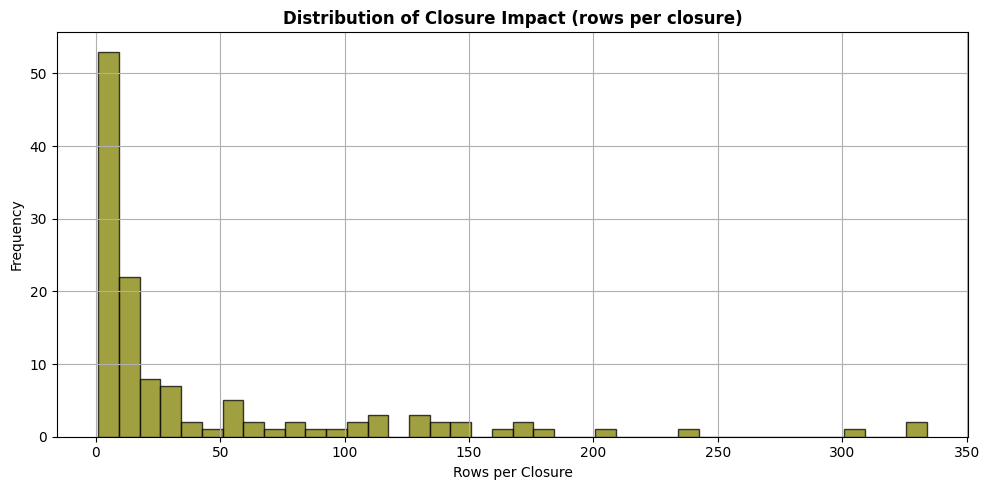

In [67]:
# Closure impact distribution
closure_counts = filtered_df.groupby("closure_id").size().sort_values(ascending=False)
print(f"Unique closures: {len(closure_counts)}")
print(f"Mean rows per closure:   {closure_counts.mean():.1f}")
print(f"Median rows per closure: {closure_counts.median():.1f}")
print(f"Max rows per closure:    {closure_counts.max()}")

plt.figure(figsize=(10, 5))
closure_counts.hist(bins=40, edgecolor="black", alpha=0.75, color="olive")
plt.xlabel("Rows per Closure")
plt.ylabel("Frequency")
plt.title("Distribution of Closure Impact (rows per closure)", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_05/closure_impact.png", dpi=200, bbox_inches="tight")
plt.show()

In [70]:
# 10-minute bucket analysis
filtered_df["time_bucket"] = pd.cut(
    filtered_df["planned_time_diff"],
    bins=[0, 10, 20, 30, 40, 50, 60],
    labels=["0-10", "10-20", "20-30", "30-40", "40-50", "50-60"]
)
bucket_ct = filtered_df.groupby(["time_bucket", "closure_type"]).size().unstack(fill_value=0)
print("Train Moments by 10-minute bucket and closure type:")
print(bucket_ct.to_string())
bucket_ct["Total"] = bucket_ct.sum(axis=1)
print(f"\nProportion per bucket:\n{(bucket_ct['Total'] / bucket_ct['Total'].sum() * 100).round(1).to_string()}")

Train Moments by 10-minute bucket and closure type:
closure_type  planned  unplanned
time_bucket                     
0-10              341        553
10-20             396        493
20-30             469        502
30-40             375        510
40-50             436        486
50-60             434        451

Proportion per bucket:
time_bucket
0-10     16.4
10-20    16.3
20-30    17.8
30-40    16.3
40-50    16.9
50-60    16.3


C:\Users\home\AppData\Local\Temp\ipykernel_16256\4044217917.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_ct = filtered_df.groupby(["time_bucket", "closure_type"]).size().unstack(fill_value=0)


## 9. Save Analytical Dataset

In [68]:
filtered_df.to_parquet("./data/processed/road_train_moments_dataset.parquet", index=False)
print(f"Saved road_train_moments dataset: {len(filtered_df):,} rows")
print("Path: data/processed/road_train_moments_dataset.parquet")
print()
print("Column summary:")
filtered_df.info()

Saved road_train_moments dataset: 5,446 rows
Path: data/processed/road_train_moments_dataset.parquet

Column summary:
<class 'pandas.core.frame.DataFrame'>
Index: 5446 entries, 79 to 94947
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   closure_id                 5446 non-null   object        
 1   closure_type               5446 non-null   object        
 2   closure_lat                5446 non-null   float64       
 3   closure_lon                5446 non-null   float64       
 4   validity_status            5446 non-null   object        
 5   cause_type                 5446 non-null   object        
 6   distance_in_km             5446 non-null   float64       
 7   station_name               5446 non-null   object        
 8   stanox                     5446 non-null   object        
 9   closure_start_time         5446 non-null   datetime64[ns]
 10  actual_timestamp 